In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import pyleoclim as pyleo
# from pyleoclim.utils.wavelet import cwt_coherence
# import scipy.signal as ss
# from scipy.interpolate import PchipInterpolator, interp1d
from pipeline import *

In [2]:
# for tr in transitions:
#     print(
#         f"Transition at t={tr['time']:.3f}s | "
#         f"{tr['from_state']} -> {tr['to_state']} | "
#         f"jump={np.degrees(tr['phase_jump']):.1f} deg | "
#         f"std={tr['std']:.3f} | "
#         f"start={tr['duration']['start']} , end={tr['duration']['end']} | "
#         # f"type: {type(tr['duration']['start'])} | "
#         f"duration={tr['duration']['length']:.3f} , {tr['duration']['state']}"
#     )

In [3]:
# Load data
# df = pd.read_excel("data/am0324_analysis/20260324_buntingphysio_bunt_am0324.xlsx")

In [4]:
# ####INTERPOLATE data####
# time_col = "time"
# angle_cols = ["p1_unwrapped", "p2_unwrapped"]
# current_cols = ["i1", "i2"]

# # 1) sort + collapse duplicate timestamps
# df = df.sort_values(time_col)
# df = df.groupby(time_col, as_index=False).mean()

# # extract columns
# cosxpi = df["time"].to_numpy() 
# p1_angle = df["angle_p1"].to_numpy()
# p2_angle = df["angle_p2"].to_numpy()
# i1 = df["i1"].to_numpy()
# i2 = df["i2"].to_numpy()
# p1 = df["p1"].to_numpy()
# p2 = df["p2"].to_numpy()

# # 2) unwrap
# p1_unwrapped = np.unwrap(p1_angle-np.pi)#+np.pi 
# p2_unwrapped = np.unwrap(p2_angle-np.pi)#+np.pi

# #add unwrapped columns to df
# df["p1_unwrapped"] = p1_unwrapped
# df["p2_unwrapped"] = p2_unwrapped

# # 3) make uniform 0.001s grid
# dt_target = 0.001
# t_new = np.arange(cosxpi.min(), cosxpi.max() + dt_target/2, dt_target)

# # 4) interpolate angles (PCHIP is shape-preserving)
# out = {time_col: t_new}

# for c in angle_cols:
#     cosx = df[c].to_numpy()
#     out[c] = PchipInterpolator(cosxpi, cosx)(t_new)

# # 5) interpolate currents (linear)
# for c in current_cols:
#     cosx = df[c].to_numpy()
#     out[c] = interp1d(cosxpi, cosx, kind="linear", bounds_error=False, fill_value="extrapolate")(t_new)

# df_rs = pd.DataFrame(out)

# # extract resampled columns
# t_rs = df_rs[time_col].to_numpy()
# p1_unwrapped_rs = df_rs["p1_unwrapped"].to_numpy()
# p2_unwrapped_rs = df_rs["p2_unwrapped"].to_numpy()
# i1_rs = df_rs["i1"].to_numpy()
# i2_rs = df_rs["i2"].to_numpy()

# # 6) compute torque + velocity
# df_rs["torque1"] = df_rs["i1"] * 0.011
# df_rs["torque2"] = df_rs["i2"] * 0.011

# df_rs["omega1"] = np.gradient(df_rs["p1_unwrapped"].to_numpy(), dt_target)
# df_rs["omega2"] = np.gradient(df_rs["p2_unwrapped"].to_numpy(), dt_target)


In [5]:
# fig, axs = plt.subplots(1, 1, figsize=(40, 10))
# axs.plot(t_rs, np.cos(p1_unwrapped_rs), label="time vs p1 angle")
# axs.plot(t_rs, np.cos(p2_unwrapped_rs), label="time vs p1 angle")
# plt.legend(fontsize=20)
# plt.xlabel("time", fontsize=20)
# plt.ylabel("angle (rad)", fontsize=20)
# plt.grid(True)
# # plt.xticks(np.arange(0, 4000, 100))

Bunting time range: 2026-03-24 10:50:07.000001 to 2026-03-24 12:00:40.070763
Physio  time range: 2026-03-24 10:50:47 to 2026-03-24 12:00:42.451546541
Serial Receive:1(1,1)    0.009502
Serial Receive:1(2,1)    0.009502
pulse_raw                0.009502
gsr_raw                  0.009502
dtype: float64
checking physio data:            time  pulse_raw   gsr_raw
3602  40.001956      516.0  0.077821


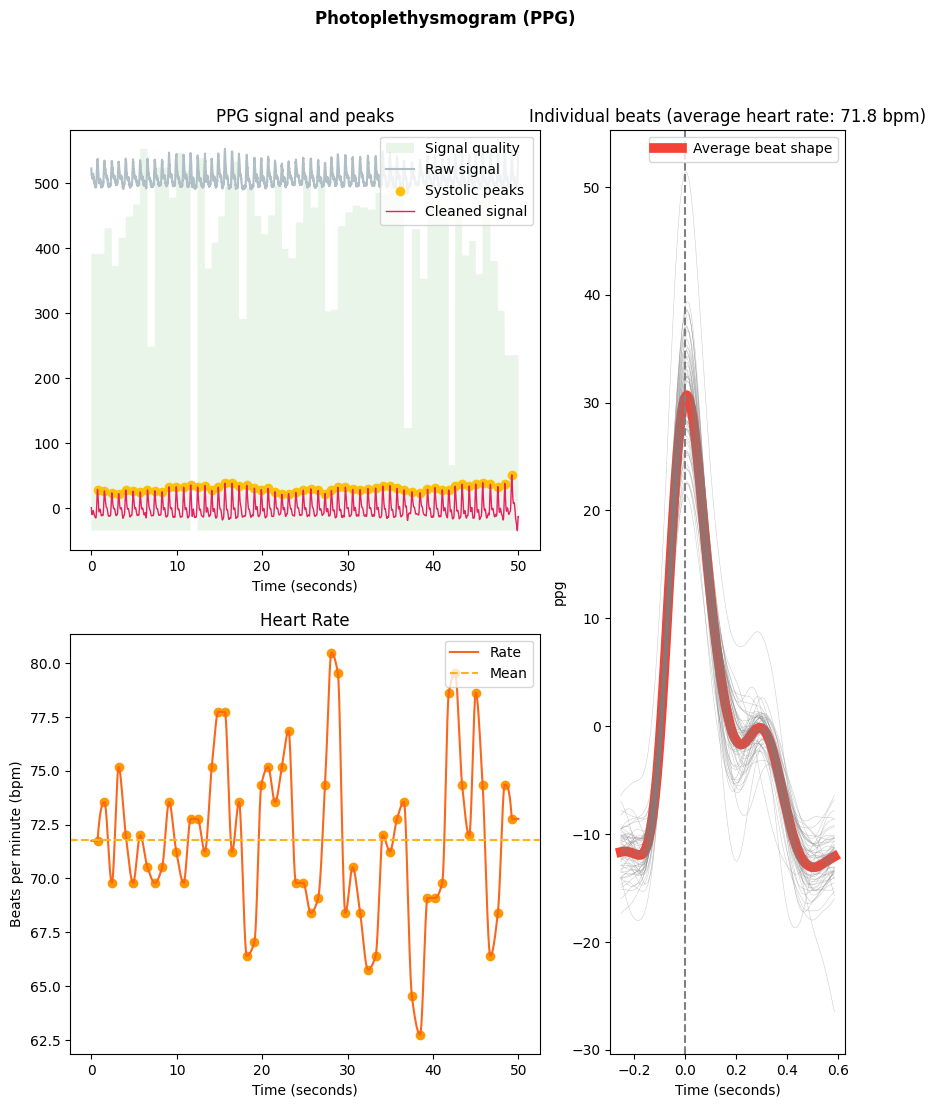

   PPG_Rate_Mean  HRV_MeanNN   HRV_SDNN  HRV_SDANN1  HRV_SDNNI1  HRV_SDANN2  \
0      71.798259  836.206897  45.249983         NaN         NaN         NaN   

   HRV_SDNNI2  HRV_SDANN5  HRV_SDNNI5  HRV_RMSSD  ...  HRV_CMSEn  HRV_RCMSEn  \
0         NaN         NaN         NaN  47.947398  ...   1.062124    1.235411   

     HRV_CD   HRV_HFD   HRV_KFD   HRV_LZC  HRV_Symbolic_EqualProb4_0V  \
0  1.880565  1.950029  3.000231  1.413995                       0.125   

   HRV_Symbolic_EqualProb4_1V  HRV_Symbolic_EqualProb4_2LV  \
0                    0.482143                        0.125   

   HRV_Symbolic_EqualProb4_2UV  
0                     0.267857  

[1 rows x 87 columns]


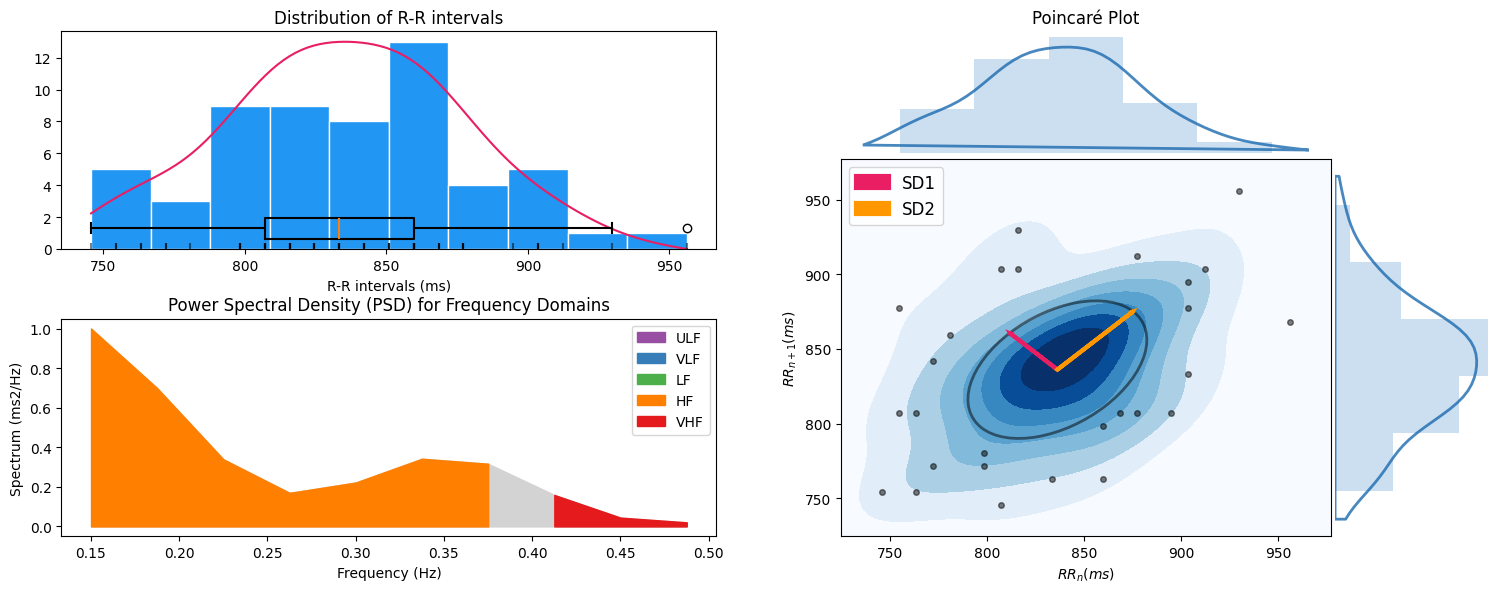

Mean BPM: 71.7982594857081


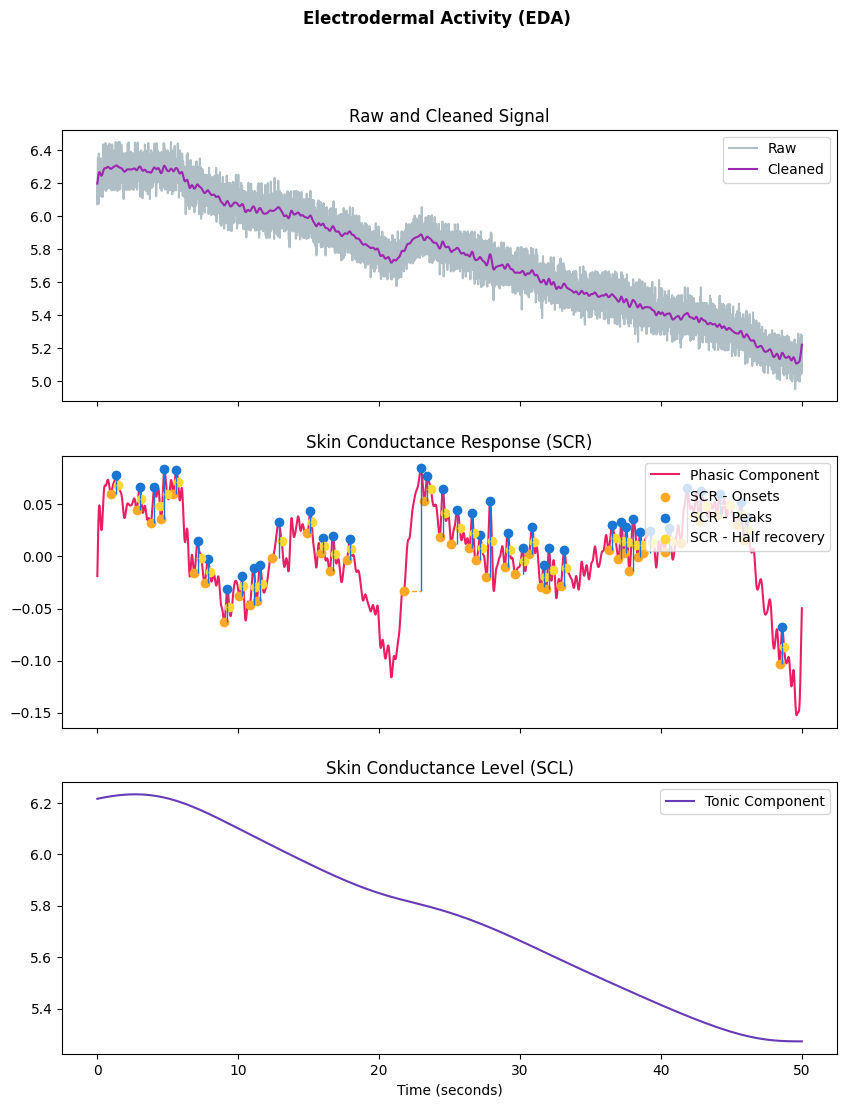

   SCR_Peaks_N  SCR_Peaks_Amplitude_Mean  EDA_Tonic_SD  EDA_Sympathetic  \
0         43.0                  0.032275      0.313643              NaN   

   EDA_SympatheticN  EDA_Autocorrelation  
0               NaN             0.728801  
SCR count: 43
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.42857143 17.5905819  57.        ]...[ 5.42857143 17.5905819  57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        ]...[ 5.18181818 17.18614664 57.        ], nfreq=3
Setting freq=[ 5.18181818 17.18614664 57.        

'\nnc0304:\nstatic practice: 1191.377166, 1292.866931: 101.48976500000003\nslow practice: 1337.248022, 1438.3563219999999: 101.10829999999987\nfast practice:1438.368602, 1534.6634119999999: 96.29480999999987\nfollower: 1770.759811, 2036.678639: 265.9188280000001\nevolved: 2365.8661429999997, 2688.2532429999997: 322.3870999999999\nindependant: 2959.679343, 3288.409335: 328.72999200000004\nhuman-human: 3507.798812, 3852.502728: 344.70391599999994\n'

In [21]:
df_processed, phase_windows, transitions, transition_summary = run_full_pipeline(
    "data/am0324_analysis/20260324_buntingphysio_bunt_am0324.xlsx",
    "data/am0324_analysis/20260324_buntingphysio_physio_am0324.xlsx",
    3200,
    # 3288-30,
    3250,
    dt=1/114,
    window_size=0.2,
    freq_band=(0.1, 100),
    phase_jump_thresh=np.deg2rad(50),
    smooth_k=3,
    min_dwell=4,
)
"""
nc0304:
static practice: 1191.377166, 1292.866931: 101.48976500000003
slow practice: 1337.248022, 1438.3563219999999: 101.10829999999987
fast practice:1438.368602, 1534.6634119999999: 96.29480999999987
follower: 1770.759811, 2036.678639: 265.9188280000001
evolved: 2365.8661429999997, 2688.2532429999997: 322.3870999999999
independant: 2959.679343, 3288.409335: 328.72999200000004
human-human: 3507.798812, 3852.502728: 344.70391599999994
"""

In [7]:
# # Sampling interval and sampling rate
# dt = np.diff(df_processed["time"]).mean()   # sec/sample
# fs = int(round(1 / dt))                     # Hz, make sure it's an integer

# # ---------------- PPG ----------------
# ppg_raw = df_processed["pulse_raw"].to_numpy()

# ppg_signals, ppg_info = nk.ppg_process(ppg_raw, sampling_rate=fs)

# nk.ppg_plot(ppg_signals, ppg_info)
# fig = plt.gcf()
# fig.set_size_inches(10, 12, forward=True)
# plt.show()

# print(nk.ppg_intervalrelated(ppg_signals, sampling_rate=fs))

# nk.hrv(ppg_signals["PPG_Peaks"], sampling_rate=fs, show=True)
# fig = plt.gcf()
# fig.set_size_inches(16, 6, forward=True)
# plt.show()

# # Optional BPM output
# print("Mean BPM:", np.nanmean(ppg_signals["PPG_Rate"]))

# # ---------------- EDA ----------------
# eda_raw = df_processed["gsr_raw"].to_numpy()

# eda_signals, eda_info = nk.eda_process(eda_raw, sampling_rate=fs)

# nk.eda_plot(eda_signals, eda_info)
# fig = plt.gcf()
# fig.set_size_inches(10, 12, forward=True)
# plt.show()

# eda_summary = nk.eda_intervalrelated(eda_signals, sampling_rate=fs)
# print(eda_summary)

# print("SCR count:", int(eda_signals["SCR_Peaks"].sum()))

In [8]:
df_processed

,time,p1_unwrapped,p2_unwrapped,i1,i2,pulse_raw,gsr_raw,omega1,omega2,torque1,torque2,bpm,eda_clean,eda_tonic,eda_phasic,scr_peaks,scr_amplitude
0,3200.000558,-3.120424,-3.250976,0.784467,0.594209,523.000000,6.200873,0.011513,-0.150609,0.008629,0.006536,71.752577,6.196534,6.215393,-0.018861,0,0.0
1,3200.009330,-3.120424,-3.252386,0.770212,0.593290,516.501119,6.070275,-0.008703,-0.124006,0.008472,0.006526,71.752577,6.202918,6.215492,-0.012577,0,0.0
2,3200.018102,-3.120424,-3.252902,0.782099,0.594776,514.884471,6.122991,-0.020689,-0.106599,0.008603,0.006543,71.752577,6.209459,6.215592,-0.006135,0,0.0
3,3200.026874,-3.120424,-3.254079,0.779571,0.592880,514.655143,6.280685,-0.025918,-0.096642,0.008575,0.006522,71.752577,6.216037,6.215691,0.000344,0,0.0
4,3200.035646,-3.120790,-3.254931,0.768600,0.593148,514.180230,6.348511,-0.025868,-0.092389,0.008455,0.006525,71.752577,6.222535,6.215790,0.006742,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,3249.956698,-2.586794,-2.916946,0.596515,0.593969,540.886974,5.047049,-0.006519,-0.093009,0.006562,0.006534,72.765957,5.201101,5.272505,-0.069595,0,0.0
5696,3249.965470,-2.587417,-2.917364,0.624706,0.595452,544.653598,5.047049,-0.012152,-0.093972,0.006872,0.006550,72.765957,5.206919,5.272505,-0.064051,0,0.0
5697,3249.974242,-2.587424,-2.918598,0.600882,0.594708,547.554794,5.167765,-0.013711,-0.089842,0.006610,0.006542,72.765957,5.212392,5.272505,-0.058855,0,0.0
5698,3249.983014,-2.587424,-2.919481,0.597496,0.595293,549.000000,5.248484,-0.009114,-0.078618,0.006572,0.006548,72.765957,5.217449,5.272505,-0.054075,0,0.0


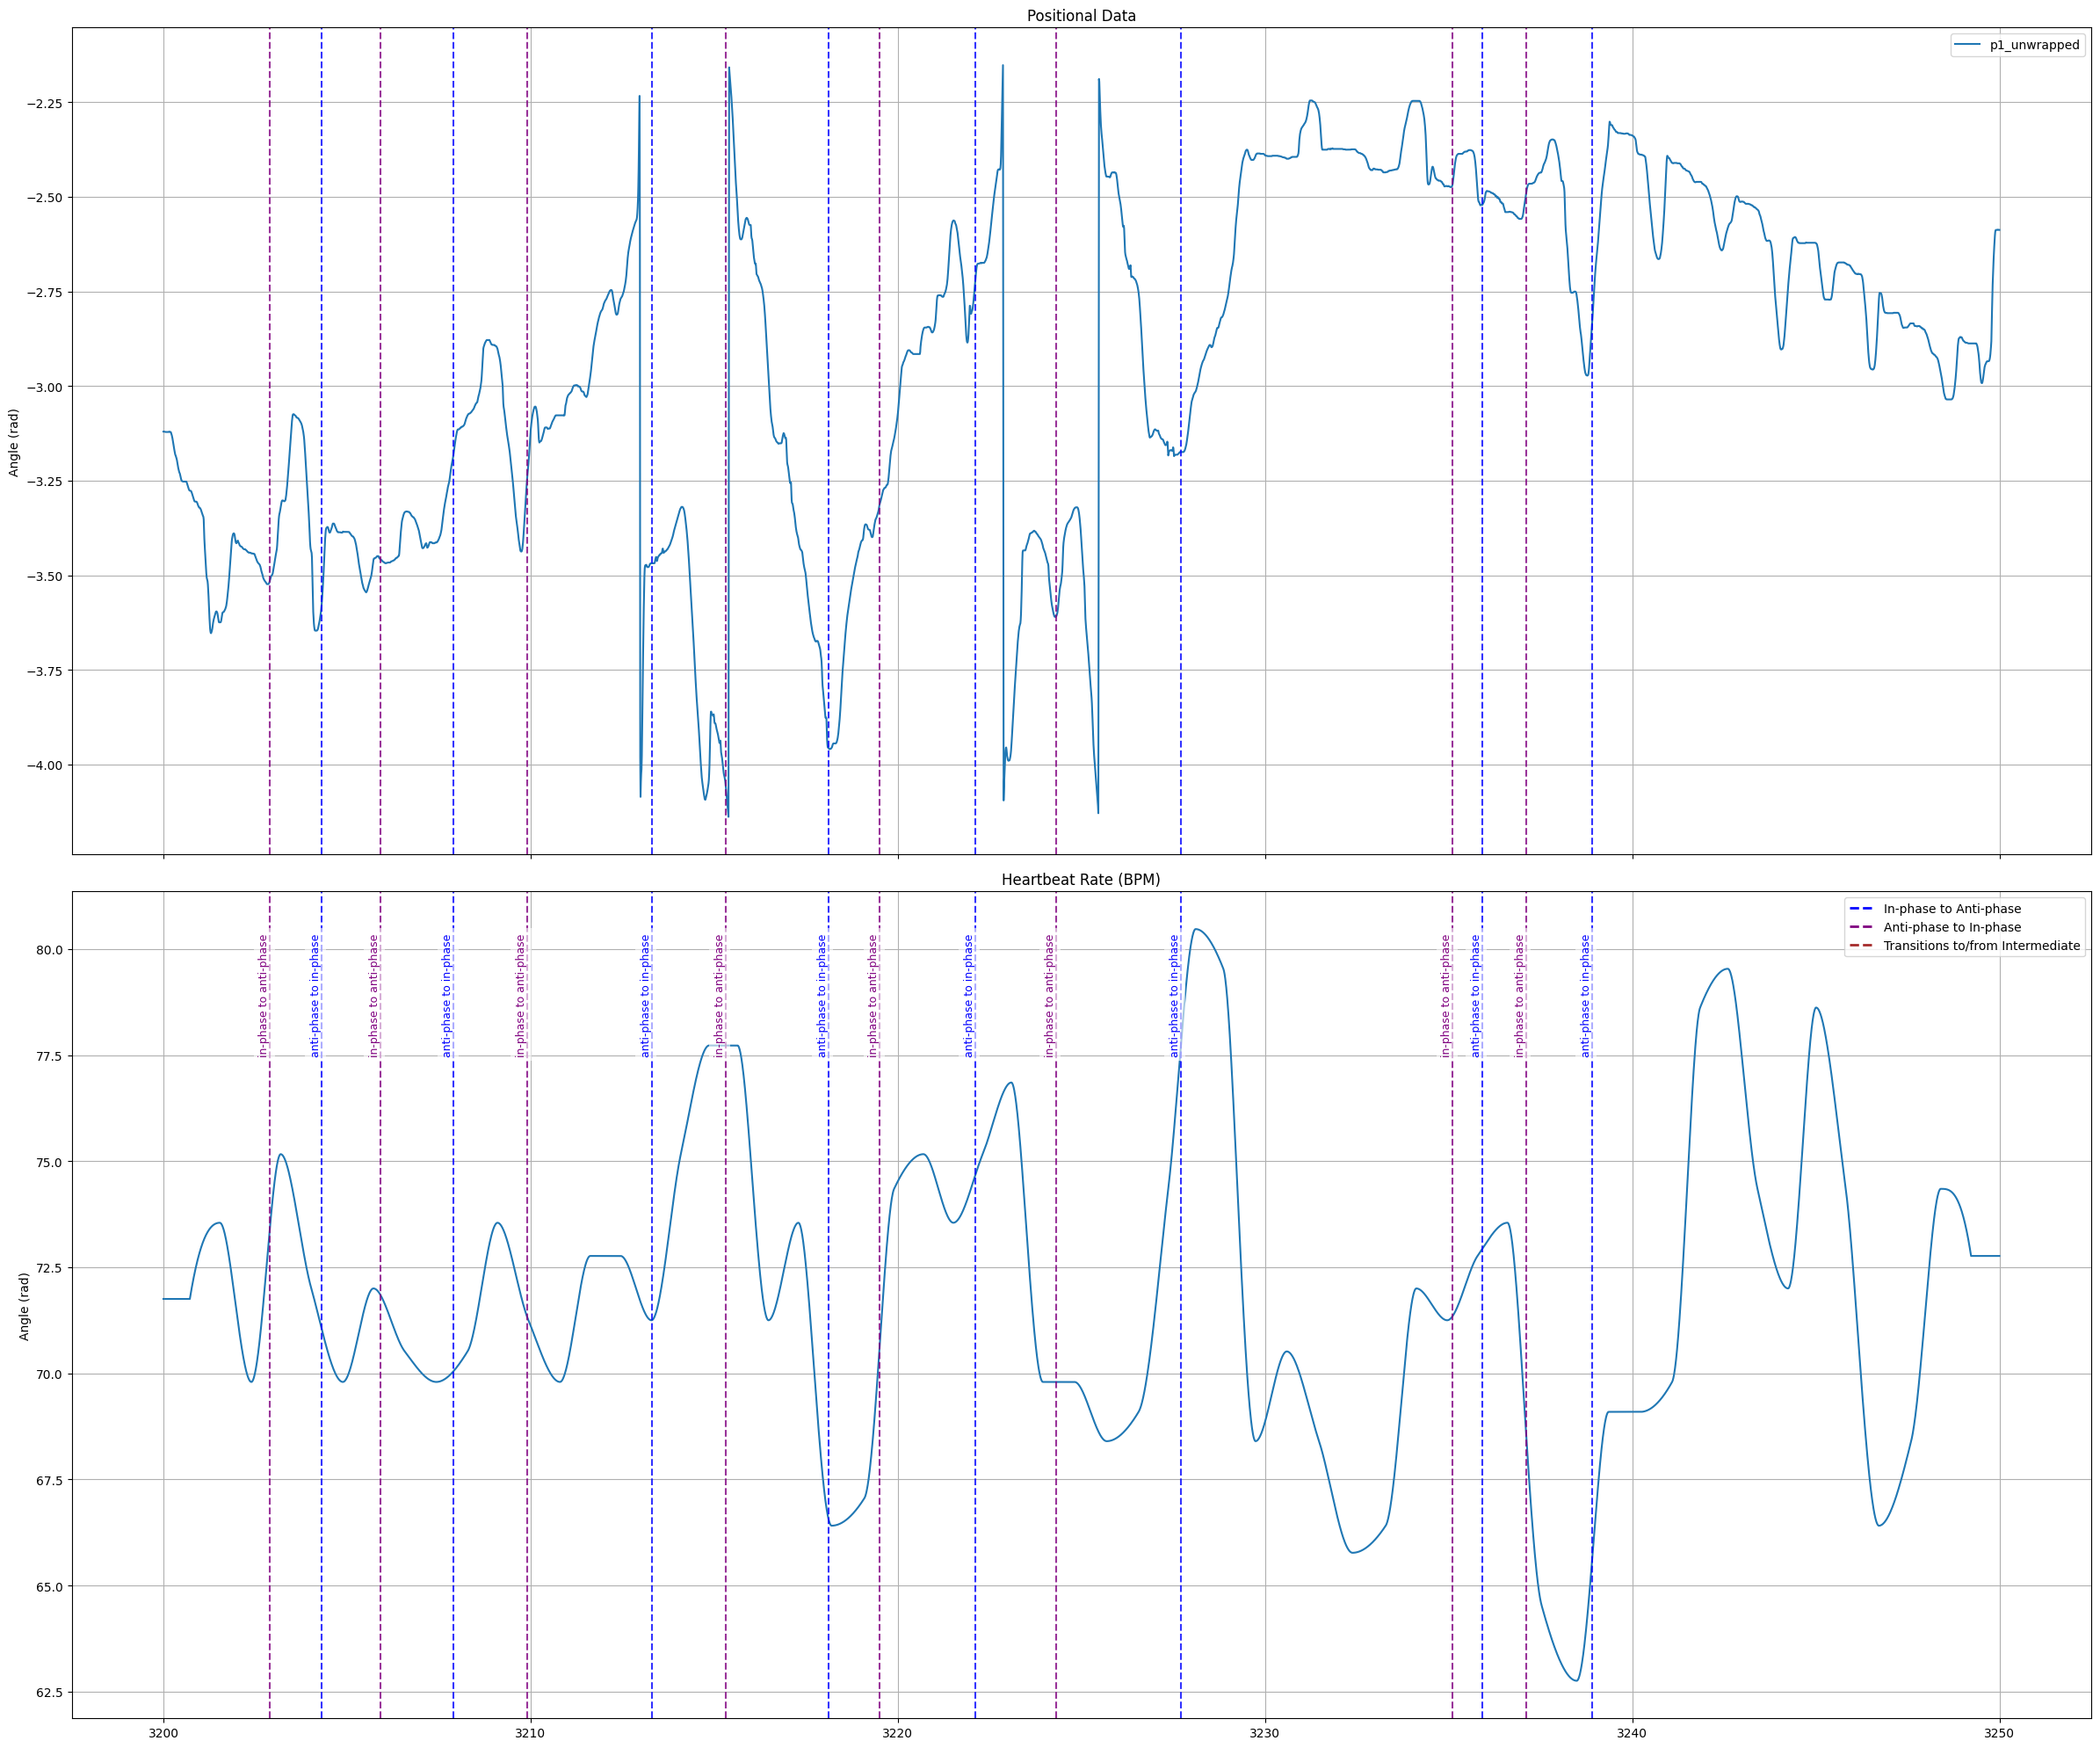

In [22]:
plot_bmp(df_processed, transitions, transition_summary)

tag in-phase to anti-phase
tr_label in-phase to anti-phase
tr_color red
tag anti-phase to in-phase
tr_label anti-phase to in-phase
tr_color green
tag in-phase to anti-phase
tr_label in-phase to anti-phase
tr_color red
tag anti-phase to in-phase
tr_label anti-phase to in-phase
tr_color green
tag in-phase to anti-phase
tr_label in-phase to anti-phase
tr_color red
tag anti-phase to in-phase
tr_label anti-phase to in-phase
tr_color green
tag in-phase to anti-phase
tr_label in-phase to anti-phase
tr_color red
tag anti-phase to in-phase
tr_label anti-phase to in-phase
tr_color green
tag in-phase to anti-phase
tr_label in-phase to anti-phase
tr_color red
tag anti-phase to in-phase
tr_label anti-phase to in-phase
tr_color green
tag in-phase to anti-phase
tr_label in-phase to anti-phase
tr_color red
tag anti-phase to in-phase
tr_label anti-phase to in-phase
tr_color green
tag in-phase to anti-phase
tr_label in-phase to anti-phase
tr_color red
tag anti-phase to in-phase
tr_label anti-phase to in

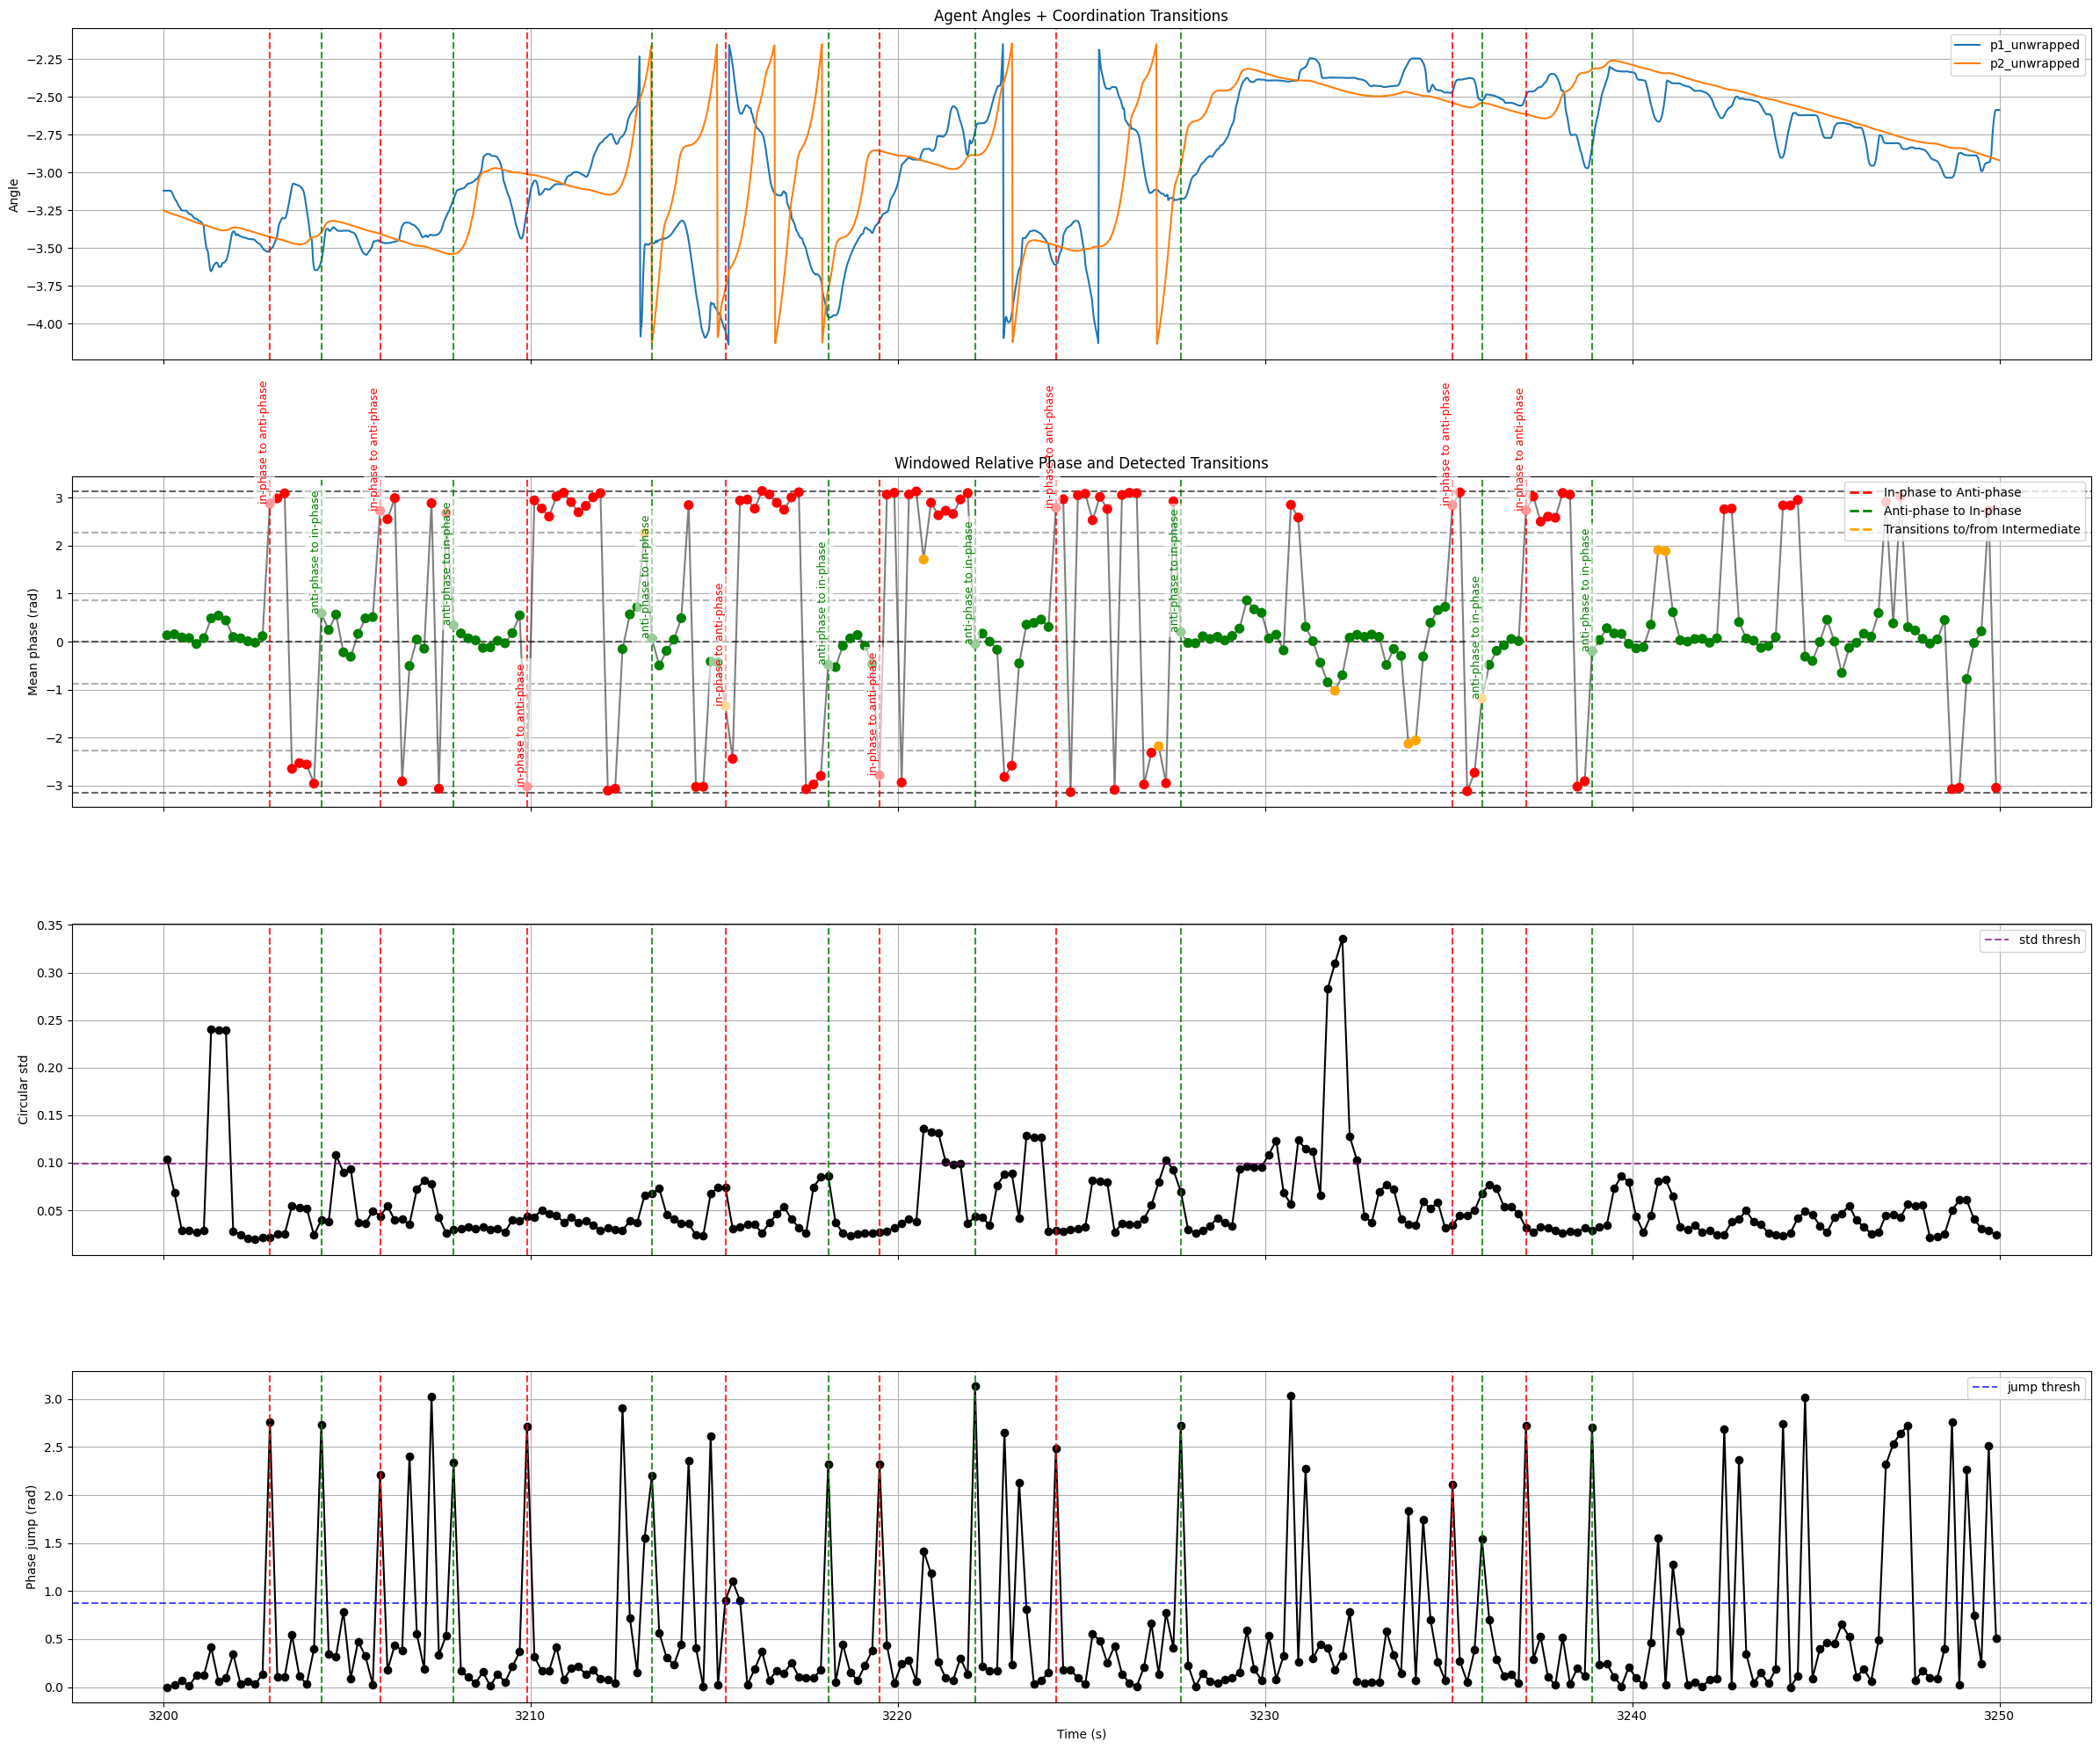

In [23]:
# plot_angles(
#     df_processed["time"],
#     df_processed["p1_unwrapped"],
#     df_processed["p2_unwrapped"],
# )

# plot_angular_velocity(
#     df_processed["time"],
#     df_processed["omega1"],
#     df_processed["omega2"],
# )

# plot_windowed_phase(phase_windows)
# plot_windowed_correlation(phase_windows)
plot_phase_transitions(transition_summary, transitions, df_processed)


In [11]:
for tr in transitions:
    print(
        f"Transition at t={tr['time']:.3f}s | "
        f"{tr['from_state']} -> {tr['to_state']} | "
        f"jump={np.degrees(tr['phase_jump']):.1f} deg | "
        f"std={tr['std']:.3f} | "
        f"start={tr['duration']['start']} , end={tr['duration']['end']} | "
        # f"type: {type(tr['duration']['start'])} | "
        f"duration={tr['duration']['length']:.3f} , {tr['duration']['state']}"
    )

Transition at t=3202.901s | in-phase -> anti-phase | jump=158.3 deg | std=0.021 | start=3200.100558 , end=3202.9005579999975 | duration=2.800 , in-phase
Transition at t=3204.301s | anti-phase -> in-phase | jump=156.8 deg | std=0.040 | start=3202.9005579999975 , end=3204.3005579999963 | duration=1.400 , anti-phase
Transition at t=3205.901s | in-phase -> anti-phase | jump=126.9 deg | std=0.044 | start=3204.3005579999963 , end=3205.900557999995 | duration=1.600 , in-phase
Transition at t=3206.701s | anti-phase -> in-phase | jump=137.9 deg | std=0.035 | start=3205.900557999995 , end=3206.700557999994 | duration=0.800 , anti-phase
Transition at t=3207.301s | in-phase -> anti-phase | jump=173.6 deg | std=0.078 | start=3206.700557999994 , end=3207.3005579999935 | duration=0.600 , in-phase
Transition at t=3207.901s | anti-phase -> in-phase | jump=133.9 deg | std=0.029 | start=3207.3005579999935 , end=3207.900557999993 | duration=0.600 , anti-phase
Transition at t=3209.901s | in-phase -> anti-p

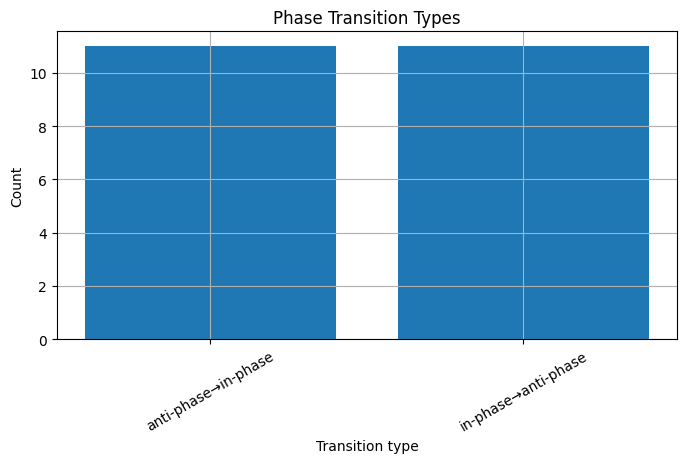

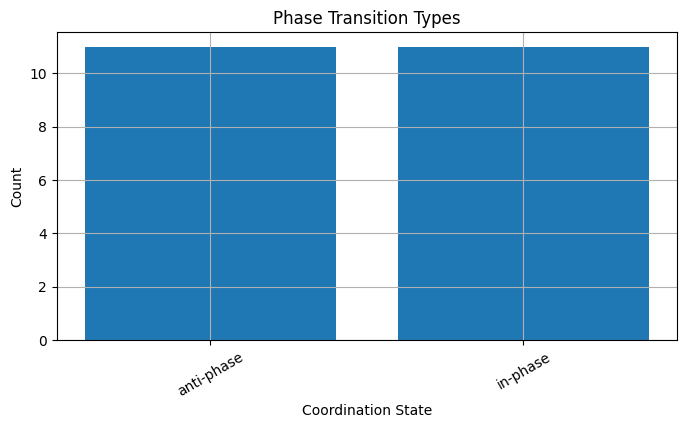

In [12]:
# plot_transition_bar(transitions)
plot_transition_types(transitions)
# plot_transition_histogram(transitions)
plot_state_histogram(transitions)

In [13]:
from pipeline import plot_transition_diagnostics
def plot_transition_diagnostics(summary, windows, transitions=None, min_dwell=5, candidate_only=True):
    """
    Debug plot for transition detection logic.

    Shows:
    1) smoothed mean phase over time
    2) candidate transition indices
    3) dwell-confirmation window for each candidate
    4) whether each future point is closer to old angle or new angle

    Parameters
    ----------
    summary : dict
        Output transition_summary from detect_phase_transitions()
    windows : list of dict
        Window list from windowed_phase_analysis()
    transitions : list of dict or None
        Accepted transitions from detect_phase_transitions()
    min_dwell : int
        Same min_dwell used in detection
    candidate_only : bool
        If True, only plot candidate indices.
        If False, also marks accepted transitions if provided.
    """
    if not summary:
        print("No summary provided.")
        return

    centers = np.asarray(summary["centers"])
    means_smooth = np.asarray(summary["means_smooth"])
    stds_smooth = np.asarray(summary["stds_smooth"])
    phase_jump = np.asarray(summary["phase_jump"])
    phase_jump_thresh = summary["phase_jump_thresh"]
    std_thresh = summary["std_thresh"]

    # same candidate logic as detect_phase_transitions
    candidate_idx = np.where(
        (phase_jump >= phase_jump_thresh) | (stds_smooth >= std_thresh)
    )[0]

    if len(candidate_idx) == 0:
        print("No candidate transitions found.")
        return

    nrows = len(candidate_idx)
    fig, axes = plt.subplots(
        nrows, 1, figsize=(18, max(4, 4 * nrows)), sharex=True
    )

    if nrows == 1:
        axes = [axes]

    accepted_idx = set()
    if transitions is not None:
        accepted_idx = {tr["idx"] for tr in transitions if "idx" in tr}

    for ax, idx in zip(axes, candidate_idx):
        if idx == 0:
            ax.set_title(f"Candidate idx={idx} skipped (no previous window)")
            continue

        old_angle = means_smooth[idx - 1]
        new_angle = means_smooth[idx]

        old_label = classify_phase_state(old_angle)
        new_label = classify_phase_state(new_angle)

        end_idx = min(len(means_smooth), idx + min_dwell)
        future_idx = np.arange(idx, end_idx)
        future = means_smooth[idx:end_idx]

        # distances used by your actual dwell logic
        d_new = np.array([circular_distance(f, new_angle) for f in future])
        d_old = np.array([circular_distance(f, old_angle) for f in future])
        stays_new = d_new < d_old

        # base trajectory
        ax.plot(centers, means_smooth, color="0.75", linewidth=1.2, zorder=1)
        ax.scatter(centers, means_smooth, color="0.6", s=18, zorder=2)

        # reference lines
        ax.axhline(0, linestyle="--", color="gray", alpha=0.5)
        ax.axhline(np.pi, linestyle="--", color="gray", alpha=0.4)
        ax.axhline(-np.pi, linestyle="--", color="gray", alpha=0.4)

        # candidate index
        ax.axvline(centers[idx], color="purple", linestyle="--", linewidth=2, zorder=3)

        # old/new anchor points
        ax.scatter(
            centers[idx - 1], old_angle,
            color="blue", s=80, zorder=5, label="old angle"
        )
        ax.scatter(
            centers[idx], new_angle,
            color="red", s=80, zorder=5, label="new angle"
        )

        # dwell window shading
        if len(future_idx) > 0:
            ax.axvspan(
                centers[future_idx[0]],
                centers[future_idx[-1]],
                color="gold",
                alpha=0.15,
                zorder=0,
            )

        # future points: green if closer to new, orange if closer to old
        for j, fidx in enumerate(future_idx):
            color = "green" if stays_new[j] else "orange"
            marker = "o" if stays_new[j] else "x"
            ax.scatter(
                centers[fidx],
                means_smooth[fidx],
                color=color,
                marker=marker,
                s=100,
                zorder=6,
            )

            ax.text(
                centers[fidx],
                means_smooth[fidx] + 0.18,
                f"{j}\nnew:{d_new[j]:.2f}\nold:{d_old[j]:.2f}",
                fontsize=8,
                ha="center",
                va="bottom",
                color=color,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
            )

        accepted = len(future) == min_dwell and np.all(stays_new)

        title = (
            f"Candidate idx={idx}, t={centers[idx]:.3f}s | "
            f"{old_label} -> {new_label} | "
            f"accepted_by_dwell={accepted}"
        )

        if transitions is not None and idx in accepted_idx:
            title += " | IN transitions[]"
        elif transitions is not None:
            title += " | NOT in transitions[]"

        ax.set_title(title)
        ax.set_ylabel("Mean phase (rad)")
        ax.grid(True, alpha=0.3)

        # compact legend text inside panel
        info = (
            f"phase_jump={phase_jump[idx]:.3f} (th={phase_jump_thresh:.3f})\n"
            f"std={stds_smooth[idx]:.3f} (th={std_thresh:.3f})\n"
            f"dwell window = [{idx}, {end_idx})  len={len(future)}\n"
            f"green = closer to NEW, orange = closer to OLD"
        )
        ax.text(
            0.01, 0.98, info,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="lightgray")
        )

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

In [14]:
# plot_transition_diagnostics(
#     transition_summary,
#     phase_windows,
#     transitions=transitions,
#     min_dwell=5,
# )

In [15]:
# # 1) check raw sliced data before resampling
# df_raw = load_and_clean_data("data/nc0304_pilot_data_truncated.xlsx")
# df = divide_data(df_raw, 3507+30, 3507+60)

# print(df[["time", "angle_p1", "angle_p2", "i1", "i2"]].isna().sum())

# # 2) check after unwrap + resample
# df_u = unwrap_angles(df.copy())
# df_rs = resample_signals(df_u, dt_target=1/114)

# print(df_rs[["p1_unwrapped", "p2_unwrapped", "i1", "i2"]].isna().sum())

# # 3) check which windows are bad
# bad = []
# for i, w in enumerate(phase_windows):
#     if np.isnan(w["mean"]) or np.isnan(w["std"]):
#         bad.append(i)

# print("bad windows:", bad[:20], "count=", len(bad))

# # 4) inspect one bad window
# i = bad[0]
# w = phase_windows[i]
# print("window", i, "start", w["start"], "end", w["end"])
# print("phi_wrapped NaNs:", np.isnan(w["phi_wrapped"]).sum())
# print("phi_wrapped len:", len(w["phi_wrapped"]))

Verification:

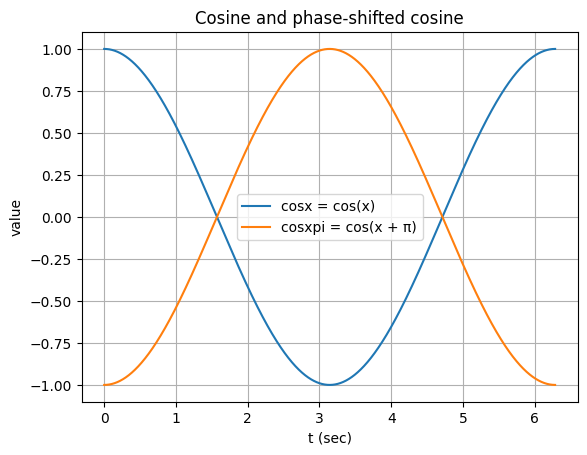

In [16]:
# x domain (radians)
x = np.linspace(0, 2*np.pi, 3894676)

# signals
cosx = np.cos(x)              # y = cos(x)
cosxpi = np.cos(x + np.pi)      # z = cos(x + pi) = -cos(x)
sh = np.cos(x +1/2*np.pi) 
sc = np.cos(x/2) 
c = 0.5
c_sig = np.full_like(x, c)

# plot
plt.figure()
plt.plot(x, cosx, label="cosx = cos(x)")
plt.plot(x, cosxpi, label="cosxpi = cos(x + π)")
# plt.plot(x, sh, label="sh = cos(x + 1/2*π)")
# plt.plot(x, sc, label="sc = cos(x/2)")
# plt.plot(x, c_sig, label="c = 0.5")   # constant line
plt.xlabel("t (sec)")
plt.ylabel("value")
plt.title("Cosine and phase-shifted cosine")
plt.grid(True)
plt.legend()
plt.show()

In [17]:

window_size=0.5
freq_band = (0, 100)
phase_jump_thresh = np.deg2rad(45)
smooth_k=3
min_dwell=2

windows = windowed_phase_analysis(
    cosx,
    cosxpi,
    t_rs,
    window_size=window_size,
    freq_band=freq_band,
)

transitions, transition_summary = detect_phase_transitions(
    windows,
    phase_jump_thresh=phase_jump_thresh,
    smooth_k=smooth_k,
    min_dwell=min_dwell,
)

NameError: name 't_rs' is not defined

In [ ]:

df_processed, phase_windows, transitions, transition_summary = run_full_pipeline(
    "data/simulated_cos_data_shifted.xlsx",
    0,
    2900,
    dt=1/114,
    window_size=0.5,
    freq_band=(0, 100),
    phase_jump_thresh=np.deg2rad(45),
    smooth_k=3,
    min_dwell=2,
)

In [ ]:
plot_angles(
    df_processed["time"],
    df_processed["p1_unwrapped"],
    df_processed["p2_unwrapped"],
)

# plot_angular_velocity(
#     df_processed["time"],
#     df_processed["omega1"],
#     df_processed["omega2"],
# )

plot_windowed_phase(phase_windows)
plot_windowed_correlation(phase_windows)
plot_phase_transitions(transition_summary, transitions, df_processed)

for tr in transitions:
    print(
        f"Transition at t={tr['time']:.3f}s | "
        f"{tr['from_state']} -> {tr['to_state']} | "
        f"jump={np.degrees(tr['phase_jump']):.1f} deg | "
        f"std={tr['std']:.3f}"
    )

In [ ]:
# plot_transition_bar(transitions)
plot_transition_types(transitions)
plot_transition_histogram(transitions)